<a href="https://colab.research.google.com/github/sabharwal-monish/Deep-Learning-Tensor-Flow/blob/main/fcc_predict_health_costs_with_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import libraries. You may or may not use all of these.
!pip install -q git+https://github.com/tensorflow/docs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
  # %tensorflow_version only exists in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

  Preparing metadata (setup.py) ... done
Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
# Import data
!wget https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
dataset = pd.read_csv('insurance.csv')
dataset.tail()

--2025-11-10 10:10:51--  https://cdn.freecodecamp.org/project-data/health-costs/insurance.csv
Resolving cdn.freecodecamp.org (cdn.freecodecamp.org)... 104.26.3.33, 172.67.70.149, 104.26.2.33, ...
Connecting to cdn.freecodecamp.org (cdn.freecodecamp.org)|104.26.3.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50264 (49K) [text/csv]
Saving to: ‘insurance.csv’

insurance.csv       100%[===================>]  49.09K  --.-KB/s    in 0s      

2025-11-10 10:10:51 (117 MB/s) - ‘insurance.csv’ saved [50264/50264]



,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [3]:
dataset.shape

(1338, 7)

In [4]:
dataset.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
expenses,float64


In [5]:
def print_unique_vals(dataset):
  for column in dataset:
    if dataset[column].dtype == 'object':
      print(f'{column}: {dataset[column].unique()}')


In [6]:
print_unique_vals(dataset)

sex: ['female' 'male']
smoker: ['yes' 'no']
region: ['southwest' 'southeast' 'northwest' 'northeast']


In [7]:
dataset['sex'] = dataset['sex'].replace({'female': 0, 'male': 1})

/tmp/ipython-input-2065331823.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['sex'] = dataset['sex'].replace({'female': 0, 'male': 1})


In [8]:
dataset['smoker'] = dataset['smoker'].replace({'yes': 0, 'no': 1})

/tmp/ipython-input-3015814941.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset['smoker'] = dataset['smoker'].replace({'yes': 0, 'no': 1})


In [9]:
dataset.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,0,27.9,0,0,southwest,16884.92
1,18,1,33.8,1,1,southeast,1725.55
2,28,1,33.0,3,1,southeast,4449.46
3,33,1,22.7,0,1,northwest,21984.47
4,32,1,28.9,0,1,northwest,3866.86


In [10]:
dataset = pd.get_dummies(dataset, columns=['region'], drop_first=True, dtype='int')

In [11]:
dataset.dtypes

,0
age,int64
sex,int64
bmi,float64
children,int64
smoker,int64
expenses,float64
region_northwest,int64
region_southeast,int64
region_southwest,int64


In [12]:
dataset.tail()

,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest
1333,50,1,31.0,3,1,10600.55,1,0,0
1334,18,0,31.9,0,1,2205.98,0,0,0
1335,18,0,36.9,0,1,1629.83,0,1,0
1336,21,0,25.8,0,1,2007.95,0,0,1
1337,61,0,29.1,0,0,29141.36,1,0,0


In [13]:
cols_to_scale = ['age', 'bmi']
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
dataset[cols_to_scale] = scaler.fit_transform(dataset[cols_to_scale])

In [14]:
dataset.tail()

,age,sex,bmi,children,smoker,expenses,region_northwest,region_southeast,region_southwest
1333,0.695652,1,0.404313,3,1,10600.55,1,0,0
1334,0.000000,0,0.428571,0,1,2205.98,0,0,0
1335,0.000000,0,0.563342,0,1,1629.83,0,1,0
1336,0.065217,0,0.264151,0,1,2007.95,0,0,1
1337,0.934783,0,0.353100,0,0,29141.36,1,0,0


In [15]:
from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)


In [16]:
train_labels = train_dataset.pop('expenses')
test_labels = test_dataset.pop('expenses')


In [17]:

model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=[len(train_dataset.keys())]),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae', 'mse'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
history = model.fit(
    train_dataset, train_labels,
    epochs=200,
    validation_split=0.2,
    verbose=1
)


Epoch 1/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 306894048.0000 - mae: 13111.1016 - mse: 306894048.0000 - val_loss: 310284384.0000 - val_mae: 12652.3086 - val_mse: 310284384.0000
Epoch 2/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 334951936.0000 - mae: 13806.5801 - mse: 334951936.0000 - val_loss: 309719552.0000 - val_mae: 12630.0215 - val_mse: 309719552.0000
Epoch 3/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 321223232.0000 - mae: 13435.8320 - mse: 321223232.0000 - val_loss: 306945696.0000 - val_mae: 12519.2266 - val_mse: 306945696.0000
Epoch 4/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 321353184.0000 - mae: 13389.0732 - mse: 321353184.0000 - val_loss: 297770560.0000 - val_mae: 12144.1172 - val_mse: 297770560.0000
Epoch 5/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 312087968.0000 - mae: 12933.5195 - mse: 312087968.0000 - val_loss: 276184000.0000 - val_mae: 11209.4307 - val_mse: 276184000.0000
Epoch 6/200
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - l

9/9 - 0s - 6ms/step - loss: 20451732.0000 - mae: 2804.5137 - mse: 20451732.0000
Testing set Mean Abs Error: 2804.51 expenses
You passed the challenge. Great job!
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


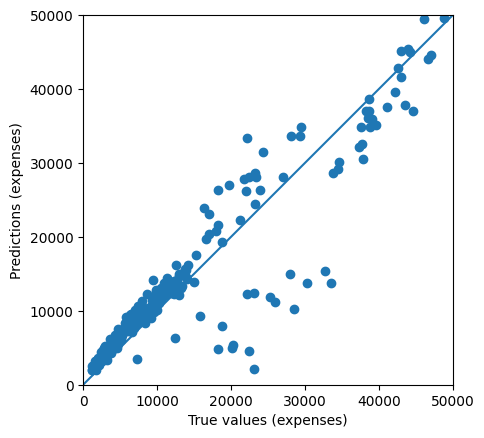

In [19]:
# RUN THIS CELL TO TEST YOUR MODEL. DO NOT MODIFY CONTENTS.
# Test model by checking how well the model generalizes using the test set.
loss, mae, mse = model.evaluate(test_dataset, test_labels, verbose=2)

print("Testing set Mean Abs Error: {:5.2f} expenses".format(mae))

if mae < 3500:
  print("You passed the challenge. Great job!")
else:
  print("The Mean Abs Error must be less than 3500. Keep trying.")

# Plot predictions.
test_predictions = model.predict(test_dataset).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True values (expenses)')
plt.ylabel('Predictions (expenses)')
lims = [0, 50000]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims,lims)
